<a href="https://colab.research.google.com/github/MuhammadNihalImran/Health_Risk_Classification-24F-AI-029/blob/main/ML_LAB_7_(open_ended).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project:** Health Risk Classification
# **Dataset:** Pima Indians Diabetes Database
# **Roll No:** YOUR_ROLL_NO

## Dataset Description

The Pima Indians Diabetes Dataset is a classification dataset used to predict
whether a patient has diabetes based on different health-related indicators.

The dataset contains medical and demographic features such as pregnancies,
glucose level, blood pressure, skin thickness, insulin level, BMI, diabetes
pedigree function, and age.

The target variable is `Outcome`:
- 0 = No Diabetes
- 1 = Diabetes

### Features:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age

### Target:
- Outcome

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "jamaltariqcheema/pima-indians-diabetes-dataset"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pima-indians-diabetes-dataset' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-dataset


In [2]:
import os

print(os.listdir(path))

['diabetes.csv']


##**1. load dataset and display**

In [3]:
import pandas as pd

df = pd.read_csv(os.path.join(path, 'diabetes.csv'))

print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


##**2. EDA**

In [4]:
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [6]:
import seaborn as sns

<Axes: xlabel='Outcome', ylabel='count'>

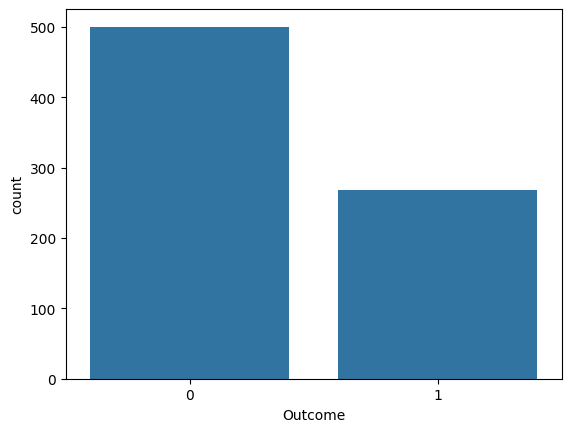

In [7]:
sns.countplot(data=df, x='Outcome')

Here,
* there is no missing values
* target columne are imblanace  





##**3. DATA preprocessing**

In [8]:
df.isnull().sum().sum()

np.int64(0)

##**4. Splitting the Data**

In [9]:
x = df.drop('Outcome', axis=1)
y = df['Outcome']

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

##**5. normalize the data**




In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scl = scaler.fit_transform(x_train)
x_test_scl = scaler.transform(x_test)

##**6. Model training**



In [12]:
from sklearn.tree import DecisionTreeClassifier

dct = DecisionTreeClassifier()
dct.fit(x_train_scl, y_train)

y_pred_train_dt = dct.predict(x_train_scl)
y_pred_test_dt = dct.predict(x_test_scl)


In [18]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(x_train_scl, y_train)

y_pred_train_sv = svc.predict(x_train_scl)
y_pred_test_sv = svc.predict(x_test_scl)

##**6. Evaluation**




In [19]:
from sklearn.metrics import accuracy_score, classification_report

print("train data",accuracy_score(y_train, y_pred_train_dt))
print("test data",accuracy_score(y_test, y_pred_test_dt))

train data 1.0
test data 0.8311688311688312


In [20]:
print("train data",accuracy_score(y_train, y_pred_train_sv))
print("test data",accuracy_score(y_test, y_pred_test_sv))

train data 0.8957654723127035
test data 0.8376623376623377


In [25]:
class_report_dt = classification_report(y_test, y_pred_test_dt)
print(class_report_dt)

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       100
           1       0.77      0.74      0.75        54

    accuracy                           0.83       154
   macro avg       0.82      0.81      0.81       154
weighted avg       0.83      0.83      0.83       154



In [26]:
class_report_sv = classification_report(y_test, y_pred_test_sv)
print(class_report_sv)

              precision    recall  f1-score   support

           0       0.88      0.87      0.87       100
           1       0.76      0.78      0.77        54

    accuracy                           0.84       154
   macro avg       0.82      0.82      0.82       154
weighted avg       0.84      0.84      0.84       154



##**7. Conclusion**




A model with very high training accuracy may not perform equally well on unseen data. In our results, Decision Tree achieved 100% training accuracy but 83.1% test accuracy, indicating overfitting. SVM achieved 89.6% training accuracy and 83.8% test accuracy, showing slightly better generalization. Therefore, test performance is more important than simply maximizing training accuracy.